In [66]:
import numpy as np 
import pandas as pd 

import statsmodels.api as sm
from utils import save_results

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, brier_score_loss, f1_score


In [69]:
df_test_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_open.csv')
df_test_close1 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close1.csv')
df_test_close2 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close2.csv')

df_train_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\train_logit_open.csv')
df_train_close1 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\train_logit_close1.csv')
df_train_close2 = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\train_logit_close2.csv')


In [68]:

def obs_per_fighter(df_test): 

    dat = []
    for _, row in df_test.iterrows():

        pred_winner = row['pred_winner'] == 1
        total_fights_red = row['num_wins_red'] + row['num_losses_red']
        total_fights_blue = row['num_wins_blue'] + row['num_losses_blue']
        total_fights_pred = total_fights_red if pred_winner else total_fights_blue
        total_fights_loser = total_fights_blue if pred_winner else total_fights_red
        total_fights_diff = total_fights_pred - total_fights_loser

        new_row = [total_fights_red, total_fights_blue, total_fights_pred, total_fights_loser, total_fights_diff]
        dat.append(new_row)
    
    return np.array(dat)


def fighter_historical_accuracy(df):

    df = df.copy()

    # ensure chronological order
    # df = df.sort_values('date')

    fighter_stats = {}

    red_acc = []
    blue_acc = []

    for _, row in df.iterrows():

        fighter_red = row['fighter_red']
        fighter_blue = row['fighter_blue']

        winner = row['winner']

        # get prior stats only (no current-row leakage)
        red_wins, red_total = fighter_stats.get(fighter_red, (0, 0))
        blue_wins, blue_total = fighter_stats.get(fighter_blue, (0, 0))

        # historical accuracy BEFORE current fight
        red_hist_acc = (
            red_wins / red_total
            if red_total > 0 else np.nan
        )

        blue_hist_acc = (
            blue_wins / blue_total
            if blue_total > 0 else np.nan
        )

        red_acc.append(red_hist_acc)
        blue_acc.append(blue_hist_acc)

        # update AFTER recording historical values
        if winner == 1:
            fighter_stats[fighter_red] = (red_wins + 1, red_total + 1)
            fighter_stats[fighter_blue] = (blue_wins, blue_total + 1)

        else:
            fighter_stats[fighter_red] = (red_wins, red_total + 1)
            fighter_stats[fighter_blue] = (blue_wins + 1, blue_total + 1)

    df['fighter_red_hist_winrate'] = red_acc
    df['fighter_blue_hist_winrate'] = blue_acc

    return df


(tf_red_open_train, tf_blue_open_train, tf_pred_open_train, tf_loser_open_train, tf_diff_open_train) = obs_per_fighter(df_train_open).T
(tf_red_open_test, tf_blue_open_test, tf_pred_open_test, tf_loser_open_test, tf_diff_open_test) = obs_per_fighter(df_test_open).T

(tf_red_close1_train, tf_blue_close1_train, tf_pred_close1_train, tf_loser_close1_train, tf_diff_close1_train) = obs_per_fighter(df_train_close1).T
(tf_red_close1_test, tf_blue_close1_test, tf_pred_close1_test, tf_loser_close1_test, tf_diff_close1_test) = obs_per_fighter(df_test_close1).T


(tf_red_close2_train, tf_blue_close2_train, tf_pred_close2_train, tf_loser_close2_train, tf_diff_close2_train) = obs_per_fighter(df_train_close2).T
(tf_red_close2_test, tf_blue_close2_test, tf_pred_close2_test, tf_loser_close2_test, tf_diff_close2_test) = obs_per_fighter(df_test_close2).T


In [63]:
train_sets = [df_train_open, df_train_close1, df_train_close2]
test_sets = [df_test_open, df_test_close1, df_test_close2]
model_cols = ['proba_red', 'proba_blue']

def get_train_test(train_sets, test_sets):
    X_train = pd.concat(
        [
            (
                dat['proba_red'] - dat['proba_blue']
            ).rename(f'proba_diff_{i}')
            for i, dat in enumerate(train_sets)
        ],
        axis=1
    )
    # X_train['total_fights'] = df_total_fights_train['total_fights']
    y_train = df_train_open['winner']


    X_test = pd.concat(
        [
            (
                dat['proba_red'] - dat['proba_blue']
            ).rename(f'proba_diff_{i}')
            for i, dat in enumerate(test_sets)
        ],
        axis=1
    )
    y_test = df_test_open['winner']
    
    return X_train, y_train, X_test, y_test

In [64]:
X_train, y_train, X_test, y_test = get_train_test(train_sets, test_sets)
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3550 entries, 0 to 3549
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   proba_diff_0  3550 non-null   float64
 1   proba_diff_1  3550 non-null   float64
 2   proba_diff_2  3550 non-null   float64
dtypes: float64(3)
memory usage: 83.3 KB


In [65]:
# add intercept
X_train_const = sm.add_constant(X_train)
print(X_train_const.info())
# logistic regression
model = sm.Logit(y_train, X_train_const)

# fit
result = model.fit()

# summary
print(result.summary())


X_test_const = sm.add_constant(X_test, has_constant='add')
pred_proba = result.predict(X_test_const)
test_accuracy = ((pred_proba >= 0.5) == y_test).mean()
print(test_accuracy)


pred = result.get_prediction(X_test_const)
pred_summary = pred.summary_frame()
print(pred_summary)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3550 entries, 0 to 3549
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   const         3550 non-null   float64
 1   proba_diff_0  3550 non-null   float64
 2   proba_diff_1  3550 non-null   float64
 3   proba_diff_2  3550 non-null   float64
dtypes: float64(4)
memory usage: 111.1 KB
None
Optimization terminated successfully.
         Current function value: 0.615206
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                 winner   No. Observations:                 3550
Model:                          Logit   Df Residuals:                     3546
Method:                           MLE   Df Model:                            3
Date:                Tue, 26 May 2026   Pseudo R-squ.:                 0.09994
Time:                        14:24:33   Log-Likelihood:                -2184.0
converged:   

In [ ]:

# accuracy
test_accuracy = ((pred_proba >= 0.5) == y_test).mean()

# brier score
brier = brier_score_loss(y_test, pred_proba)

print("Accuracy:", test_accuracy)
print("Brier Score:", brier)

Accuracy: 0.7001594896331739
Brier Score: 0.1960143367528182


In [56]:
X_train, y_train, X_test, y_test = get_train_test(train_sets, test_sets)

In [ ]:


# X_train['proba_se_open'] = df_train_open['proba_se']
# X_test['proba_se_open'] = df_test_open['proba_se']

# X_train['fighter_red_hist_winrate'] = df_win_pct_train['fighter_red_hist_winrate']
# X_test['fighter_red_hist_winrate'] = df_win_pct_test['fighter_red_hist_winrate']


X_train['total_fights_pred_open'] = tf_pred_open_train
X_test['total_fights_pred_open'] = tf_pred_open_test


# X_train['total_fights_pred_close1'] = tf_pred_close1_train
# X_test['total_fights_pred_close1'] = tf_pred_close1_test

# X_train['total_fights_pred_close2'] = tf_pred_close2_train
# X_test['total_fights_pred_close2'] = tf_pred_close2_test

# X_train['total_fights_diff_open'] = tf_diff_open_train
# X_test['total_fights_diff_open'] = tf_diff_open_test


# model
model = XGBClassifier(
    n_estimators=200,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
)

# train
model.fit(X_train, y_train)

# predicted probabilities
test_probs = model.predict_proba(X_test)
pred_proba = model.predict_proba(X_test)[:, 1]

# predicted class
pred_class = (pred_proba >= 0.5).astype(int)

# metrics
test_accuracy = accuracy_score(y_test, pred_class)
brier = brier_score_loss(y_test, pred_proba)
f1 = f1_score(y_test, pred_class)
print("Test Accuracy:", test_accuracy)
print("Brier Score:", brier)
print('F1 Score: ', f1)

Test Accuracy: 0.7145135566188198
Brier Score: 0.19497967674975591
F1 Score:  0.7417027417027418


In [58]:
train_proba = model.predict_proba(X_train)[:,1]
train_pred_class = (train_proba >= .5).astype(int)

print('Train Accuracy: ', accuracy_score(y_train, train_pred_class))
print('Train Brier: ', brier_score_loss(y_train, train_proba))
print('Train F1: ', f1_score(y_train, train_pred_class))

Train Accuracy:  0.6726760563380282
Train Brier:  0.2066372337255243
Train F1:  0.7268453220498354


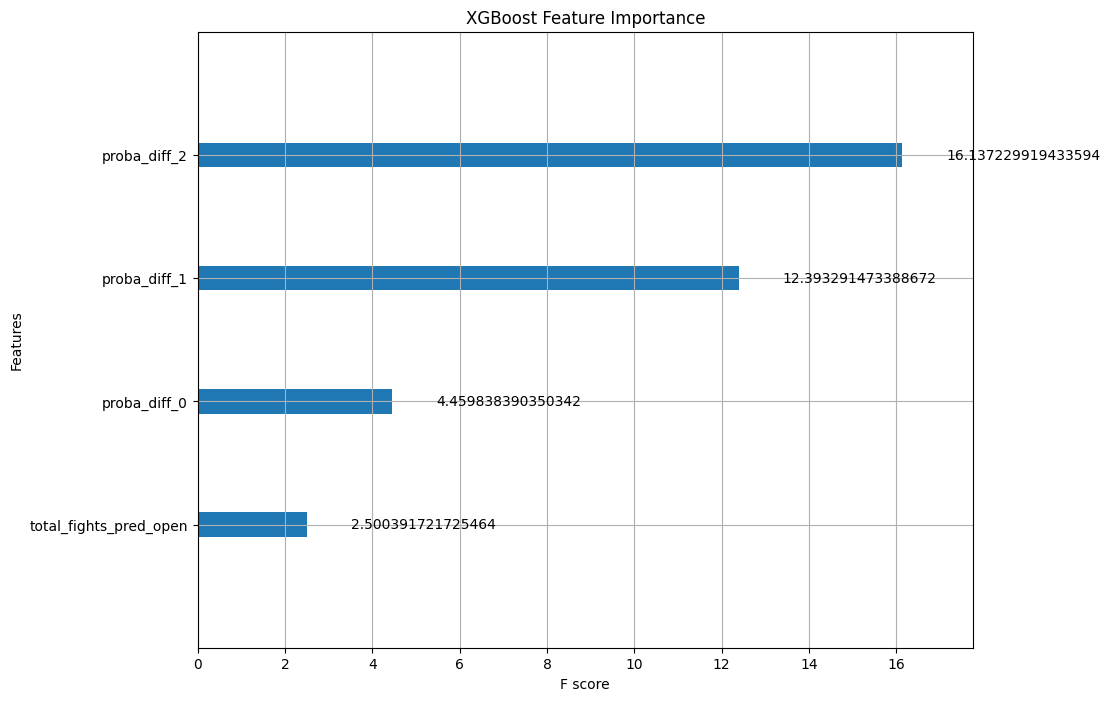

In [59]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

plot_importance(
    model,
    ax=ax,
    importance_type='gain',   # 'weight', 'gain', 'cover'
    max_num_features=20
)

plt.title("XGBoost Feature Importance")
plt.show()

In [ ]:
df_stack_close1 = pd.DataFrame({
    "winner":y_test,
    'event_date': df_test_open['date'],
    'dec_fair_close1_red':df_test_close1['dec_fair_close1_red'],
    'dec_fair_close1_blue':df_test_close1['dec_fair_close1_blue'],
    'dec_close1_blue': df_test_close1['dec_close1_blue'], 
    'dec_close1_red': df_test_close1['dec_close1_red'],
    'fighter_red':df_test_open['fighter_red'],
    'fighter_blue':df_test_open['fighter_blue'],
    'date':df_test_open['date'],
    'open_red':df_test_open['open_red'],
    'open_blue':df_test_open['open_blue'],
    'close1_red': df_test_close1['close1_red'],
    'close1_blue': df_test_close1['close1_blue'],
    'close2_red': df_test_close2['close2_red'],
    'close2_blue': df_test_close2['close2_blue'],
    'close1_red': df_test_close1['close1_red'],
    'close1_blue': df_test_close1['close1_blue'],
    'close2_red': df_test_close2['close2_red'],
    'close2_blue': df_test_close2['close2_blue'],

    'juice_open_red': df_test_close1['juice_open_red'],
    'juice_open_blue': df_test_close1['juice_open_blue'],

    'juice_close1_red': df_test_close1['juice_close1_red'],
    'juice_close1_blue': df_test_close1['juice_close1_blue'],

    'juice_close2_red': df_test_close2['juice_close2_red'],
    'juice_close2_blue': df_test_close2['juice_close2_blue'],
    'date': df_test_close1['date']
})

df_stack_close2 = pd.DataFrame({
    "winner":y_test,
    'event_date': df_test_open['date'],
    'dec_fair_close2_red':df_test_close2['dec_fair_close2_red'],
    'dec_fair_close2_blue':df_test_close2['dec_fair_close2_blue'],
    'dec_close2_blue': df_test_close2['dec_close2_blue'], 
    'dec_close2_red': df_test_close2['dec_close2_red'],
    'fighter_red':df_test_open['fighter_red'],
    'fighter_blue':df_test_open['fighter_blue'],
    'date':df_test_open['date'],

    'open_red':df_test_open['open_red'],
    'open_blue':df_test_open['open_blue'],

    'close1_red': df_test_close1['close1_red'],
    'close1_blue': df_test_close1['close1_blue'],

    'close2_red': df_test_close2['close2_red'],
    'close2_blue': df_test_close2['close2_blue'],

    'juice_open_red': df_test_close1['juice_open_red'],
    'juice_open_blue': df_test_close1['juice_open_blue'],

    'juice_close1_red': df_test_close1['juice_close1_red'],
    'juice_close1_blue': df_test_close1['juice_close1_blue'],

    'juice_close2_red': df_test_close2['juice_close2_red'],
    'juice_close2_blue': df_test_close2['juice_close2_blue'],
    'date': df_test_close1['date']
})



In [ ]:
df_results_close1 = save_results(df_test_close1, test_probs, r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_xboost_stack_close1.csv')
df_results_close2 = save_results(df_test_close2, test_probs, r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_xboost_stack_close2.csv')



In [111]:
model.save_model(r"C:\\Users\\jcmar\\my_files\\SportsBetting\\data\\saved_models\\xgboost_stacked.pkl")
    

c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [00:13:47] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)
